In [1]:
import os

BASE_PATH = "/content/drive/MyDrive/motamot_xlm"

# Create folders if they don't exist
os.makedirs(f"{BASE_PATH}/original_dataset", exist_ok=True)
os.makedirs(f"{BASE_PATH}/preprocessed_dataset", exist_ok=True)
os.makedirs(f"{BASE_PATH}/results", exist_ok=True)

print(f"Base path: {BASE_PATH}")
print("Folders ready:")
print(f"  - {BASE_PATH}/original_dataset")
print(f"  - {BASE_PATH}/preprocessed_dataset")
print(f"  - {BASE_PATH}/results")

Base path: /content/drive/MyDrive/motamot_xlm
Folders ready:
  - /content/drive/MyDrive/motamot_xlm/original_dataset
  - /content/drive/MyDrive/motamot_xlm/preprocessed_dataset
  - /content/drive/MyDrive/motamot_xlm/results


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load and examine split data
import pandas as pd
import numpy as np
import os
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Load pre-split data
train = pd.read_csv(f"{BASE_PATH}/original_dataset/train.csv")
val = pd.read_csv(f"{BASE_PATH}/original_dataset/validation.csv")
test = pd.read_csv(f"{BASE_PATH}/original_dataset/test.csv")

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)
print("\nTrain columns:", train.columns.tolist())
print("\nFirst few rows of train:")
print(train.head(3))

Train shape: (5647, 6)
Val shape: (705, 6)
Test shape: (706, 6)

Train columns: ['source_link', 'newspaper_name', 'published_date', 'headline', 'short_description', 'sentiment']

First few rows of train:
                                         source_link newspaper_name  \
0  জাল ভোট হলে কেন্দ্রের কারও চাকরি থাকবে না: ইসি...   একাত্তর টিভি   
1              ভয়-ভীতি উপেক্ষা করে ভোট দেয়ার আহবান   একাত্তর টিভি   
2  বৃহস্পতিবার ছয় জেলার জনসভায় বক্তব্য দেবেন শে...   একাত্তর টিভি   

     published_date                                           headline  \
0  ২৭ ডিসেম্বর ২০২৩  জাল ভোট হলে কেন্দ্রের কারও চাকরি থাকবে না: ইসি...   
1  ২৭ ডিসেম্বর ২০২৩                ভয়-ভীতি উপেক্ষা করে ভোট দেয়ার আহবান   
2  ২৭ ডিসেম্বর ২০২৩  বৃহস্পতিবার ছয় জেলার জনসভায় বক্তব্য দেবেন শেখ ...   

                                   short_description sentiment  
0  নির্বাচন কমিশনার আহসান হাবিব খান বলেছেন, কোনো ...  Positive  
1  বিএনপি ও জামায়াতে ইসলামী কোনো রাজনৈতিক দল হিসে...  Positive  
2  দ্বাদশ জাতীয় সংস

In [4]:
# Check label distribution in splits
# TEXT_COL = "short_description"
# LABEL_COL = "sentiment"

TEXT_COL = "short_description"
LABEL_COL = "sentiment"

def check_distribution(df, name):
    print(f"\n{name} distribution:")
    print(df[LABEL_COL].value_counts())
    print(df[LABEL_COL].value_counts(normalize=True).round(3))

check_distribution(train, "Train")
check_distribution(val, "Validation")
check_distribution(test, "Test")

# Check split ratio
total = len(train) + len(val) + len(test)
print(f"\nSplit ratios:")
print(f"Train: {len(train)/total:.2%}")
print(f"Val: {len(val)/total:.2%}")
print(f"Test: {len(test)/total:.2%}")


Train distribution:
sentiment
Positive    3306
Negative    2341
Name: count, dtype: int64
sentiment
Positive    0.585
Negative    0.415
Name: proportion, dtype: float64

Validation distribution:
sentiment
Positive    413
Negative    292
Name: count, dtype: int64
sentiment
Positive    0.586
Negative    0.414
Name: proportion, dtype: float64

Test distribution:
sentiment
Positive    413
Negative    293
Name: count, dtype: int64
sentiment
Positive    0.585
Negative    0.415
Name: proportion, dtype: float64

Split ratios:
Train: 80.01%
Val: 9.99%
Test: 10.00%


In [5]:
# Convert to 0/1 for evaluation

def prepare_data(df):
    """Convert dataframe to format needed for evaluation"""
    df = df.copy()

    # Keep only necessary columns
    df = df[[TEXT_COL, LABEL_COL]]

    # Rename for consistency
    df = df.rename(columns={TEXT_COL: "text", LABEL_COL: "label"})

    # Convert to string and ensure no nulls
    df["text"] = df["text"].astype(str)
    df = df.dropna(subset=["text", "label"])
    df = df[df["text"].str.strip().astype(bool)]  # Remove empty texts

    # Convert labels to binary (Positive=1, Negative=0)
    df["label"] = df["label"].map({"Positive": 1, "Negative": 0})

    # Remove any rows where mapping failed
    df = df.dropna(subset=["label"])
    df["label"] = df["label"].astype(int)

    return df

# Prepare each split
train_bin = prepare_data(train)
val_bin = prepare_data(val)
test_bin = prepare_data(test)

print("Train shape:", train_bin.shape)
print("Label distribution in train:")
print(train_bin["label"].value_counts())
print(f"0 = Negative, 1 = Positive")

# Save binary versions
train_bin.to_csv(f"{BASE_PATH}/preprocessed_dataset/Motamot_train_binary.csv", index=False)
val_bin.to_csv(f"{BASE_PATH}/preprocessed_dataset/Motamot_val_binary.csv", index=False)
test_bin.to_csv(f"{BASE_PATH}/preprocessed_dataset/Motamot_test_binary.csv", index=False)

Train shape: (5647, 2)
Label distribution in train:
label
1    3306
0    2341
Name: count, dtype: int64
0 = Negative, 1 = Positive


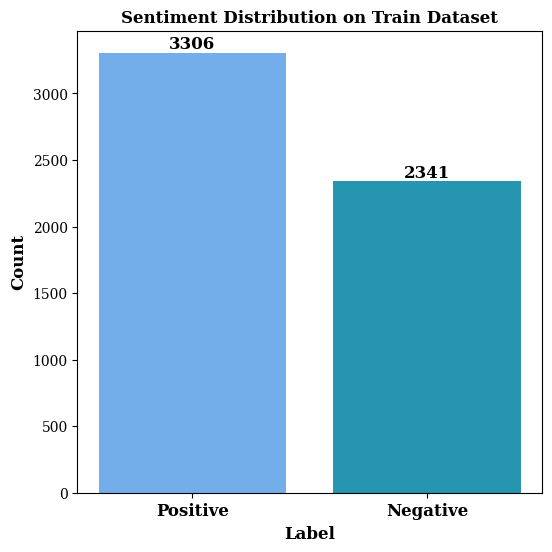

In [6]:
# Visualization of Label Distribution in Train Dataset
label_counts = train['sentiment'].value_counts()

# Define custom colors for the bars
custom_colors = ['#73aeea', '#2595b0']

# Define custom font dictionary for title and labels
font = {'family': 'Serif', 'weight': 'bold', 'size': 12}

plt.figure(figsize=(6, 6))

# Create bar plot with grid
bars = plt.bar(label_counts.index, label_counts.values, color=custom_colors)

# Set title and axis labels using custom fontdict
plt.title('Sentiment Distribution on Train Dataset', fontdict=font)
plt.xlabel('Label', fontdict=font)
plt.ylabel('Count', fontdict=font)

# Set custom font for ticks on both x and y axes
plt.xticks(label_counts.index, label_counts.index, fontdict=font)
plt.yticks(fontname='Serif', fontsize=10)

# Adding annotations (count values) on top of each bar
for bar, count in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
             ha='center', va='bottom', fontdict=font)

plt.show()

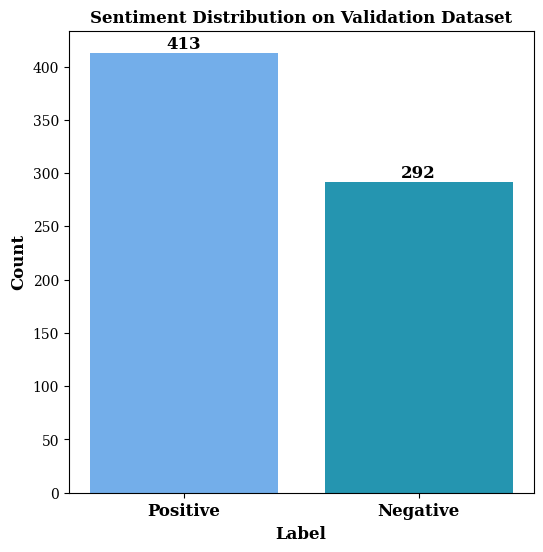

In [7]:
# Visualization of Label Distribution in Validation Dataset
label_counts = val['sentiment'].value_counts()

plt.figure(figsize=(6, 6))

bars = plt.bar(label_counts.index, label_counts.values, color=custom_colors)

plt.title('Sentiment Distribution on Validation Dataset', fontdict=font)
plt.xlabel('Label', fontdict=font)
plt.ylabel('Count', fontdict=font)

plt.xticks(label_counts.index, label_counts.index, fontdict=font)
plt.yticks(fontname='Serif', fontsize=10)

for bar, count in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
             ha='center', va='bottom', fontdict=font)

plt.show()

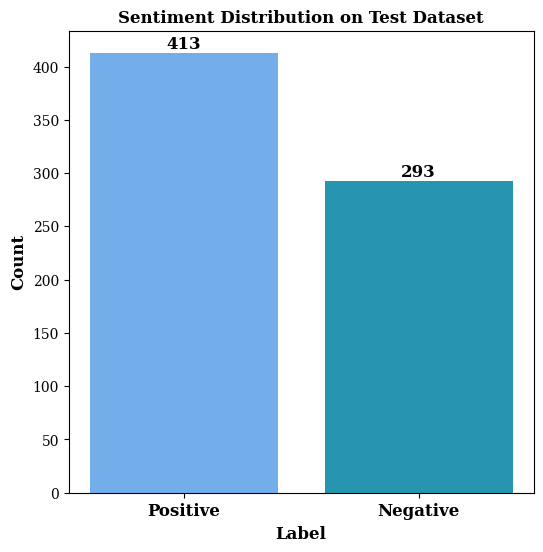

In [8]:
# Visualization of Label Distribution in Test Dataset
label_counts = test['sentiment'].value_counts()

plt.figure(figsize=(6, 6))

bars = plt.bar(label_counts.index, label_counts.values, color=custom_colors)

plt.title('Sentiment Distribution on Test Dataset', fontdict=font)
plt.xlabel('Label', fontdict=font)
plt.ylabel('Count', fontdict=font)

plt.xticks(label_counts.index, label_counts.index, fontdict=font)
plt.yticks(fontname='Serif', fontsize=10)

for bar, count in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
             ha='center', va='bottom', fontdict=font)

plt.show()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Map:   0%|          | 0/706 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ZERO-SHOT EVALUATION - HONEST APPROACH
Model: cardiffnlp/twitter-xlm-roberta-base-sentiment
Test samples: 706

Accuracy: 0.0326 (3.26%)
F1-score: 0.0527 (5.27%)

Confusion Matrix [ [TN FP], [FN TP] ]:
[[  4 289]
 [394  19]]

Classification Report:
              precision    recall  f1-score   support

         NEG       0.01      0.01      0.01       293
         POS       0.06      0.05      0.05       413

    accuracy                           0.03       706
   macro avg       0.04      0.03      0.03       706
weighted avg       0.04      0.03      0.04       706


Neutral predictions: 680 (96.32%)
  True Negative → Neutral: 288
  True Positive → Neutral: 392


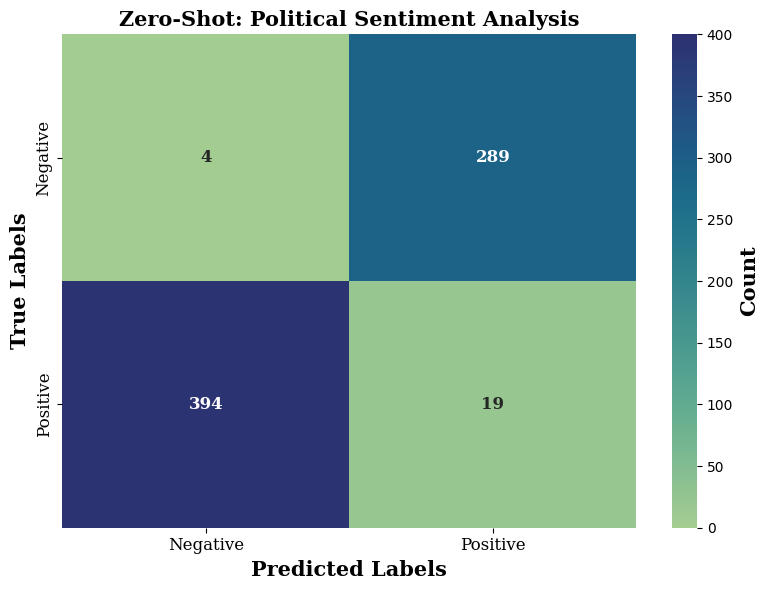


ZERO-SHOT ERROR ANALYSIS
Total Misclassified: 683
False Positives (NEG→POS): 289
False Negatives (POS→NEG): 394

ZERO-SHOT FALSE NEGATIVES (POS predicted as NEG)

True: POS | Pred: NEG (model said: NEU)
Text: দ্বাদশ সংসদ নির্বাচনে গাইবান্ধা-১ (সুন্দরগঞ্জ) আসনে  ঢেঁকি প্রতীকের স্বতন্ত্র প্রার্থী ইঞ্জিনিয়ার আব্দুল্লাহ নাহিদ নিগার সাগর বেসরকারিভাবে জয়ী হয়েছেন।রবিবার (৭ জানুয়ারি) রাত ৯ টার দিকে সুন্দরগঞ্জ উপজে...

True: POS | Pred: NEG (model said: NEU)
Text:  তথ্য ও সম্প্রচারমন্ত্রী এবং আওয়ামী লীগের যুগ্ম সাধারণ সম্পাদক ড. হাছান মাহমুদ বলেছেন, ‘আমাদের দল নতুন সরকার গঠনের পর প্রথম চ্যালেঞ্জ হবে অগ্নিসন্ত্রাস সমূলে উৎপাটন এবং স্মার্ট বাংলাদেশ গঠন।’আজ বুধবা...

True: POS | Pred: NEG (model said: NEU)
Text:  কয়েক ঘণ্টার ব্যবধানে সিদ্ধান্ত বদলাল জাতীয় পার্টি (জাপা)। সর্বশেষ সিদ্ধান্ত হলো- দলটির নবনির্বাচিত সংসদ সদস্যরা আজ বুধবারই শপথ নেবেন। এর আগে গতকাল মঙ্গলবার দুপুরে দলটি জানিয়েছিল, তারা বুধবার শপথ ন...

True: POS | Pred: NEG (model said: NEU)
Text: ঢাকা-৮ আসনে আওয়ামী লীগের প্রার্থী আওয়

In [9]:
#Zero-shot evaluation code - HONEST APPROACH (neutral counts as wrong)
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from transformers import DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import os
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

# 1) Load binary test
test_df = pd.read_csv(f"{BASE_PATH}/preprocessed_dataset/Motamot_test_binary.csv")
test_df = test_df.rename(columns={"text": "text", "label": "label"})
test_df["text"] = test_df["text"].astype(str)
test_df["label"] = test_df["label"].astype(int)

# 2) HF dataset
test_ds = Dataset.from_pandas(test_df[["text", "label"]])

# 3) Tokenize
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

test_ds = test_ds.map(tok, batched=True)
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# 4) Load model (3-class head: neg/neu/pos)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

# 5) Predict (NO training)
trainer = Trainer(model=model, data_collator=collator)
pred = trainer.predict(test_ds)

logits = pred.predictions
pred_3class = np.argmax(logits, axis=1)  # 0=neg, 1=neu, 2=pos

# 6) evaluation: neutrals count as wrong
y_true = test_df["label"].values

# Map positive (2) → 1, negative (0) → 0
pred_mapped = np.where(pred_3class == 2, 1, 0)

# Create honest predictions: neutrals forced to be wrong
pred_honest = pred_mapped.copy()
neutral_mask = (pred_3class == 1)
pred_honest[neutral_mask] = 1 - y_true[neutral_mask]  # Force opposite of true label

# 7) Metrics
acc = accuracy_score(y_true, pred_honest)
f1 = f1_score(y_true, pred_honest)
cm = confusion_matrix(y_true, pred_honest)

# Neutral breakdown
neutral_on_neg = np.sum((y_true == 0) & (pred_3class == 1))
neutral_on_pos = np.sum((y_true == 1) & (pred_3class == 1))
total_neutral = np.sum(neutral_mask)

print("="*60)
print("ZERO-SHOT EVALUATION - HONEST APPROACH")
print("="*60)
print(f"Model: {MODEL_NAME}")
print(f"Test samples: {len(test_df)}")
print(f"\nAccuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"F1-score: {f1:.4f} ({f1*100:.2f}%)")
print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, pred_honest, target_names=["NEG", "POS"]))
print(f"\nNeutral predictions: {total_neutral} ({total_neutral/len(y_true)*100:.2f}%)")
print(f"  True Negative → Neutral: {neutral_on_neg}")
print(f"  True Positive → Neutral: {neutral_on_pos}")

# 8) Save results
with open(f"{BASE_PATH}/results/motamot_zero_shot.txt", "w", encoding="utf-8") as f:
    f.write(f"MODEL: {MODEL_NAME}\n")
    f.write("DATASET: Motamot (binary: 0=NEG, 1=POS)\n")
    f.write("EVALUATION: Honest approach (neutral predictions count as wrong)\n\n")
    f.write(f"Test samples: {len(test_df)}\n")
    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"F1-score: {f1:.4f}\n\n")
    f.write("Confusion Matrix [ [TN FP], [FN TP] ]:\n")
    f.write(str(cm) + "\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_true, pred_honest, target_names=["NEG", "POS"]))
    f.write(f"\nNeutral predictions: {total_neutral} ({total_neutral/len(y_true)*100:.2f}%)\n")
    f.write(f"  True Negative → Neutral: {neutral_on_neg}\n")
    f.write(f"  True Positive → Neutral: {neutral_on_pos}\n")

# 9) Zero-Shot Confusion Matrix Heatmap
plt.figure(figsize=(8,6))
custom_palette = sns.color_palette("crest", as_cmap=True)
font = {'family': 'Serif', 'weight': 'bold', 'size': 15}

heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap=custom_palette, vmin=0, vmax=400,
                      xticklabels=['Negative', 'Positive'],
                      yticklabels=['Negative', 'Positive'],
                      annot_kws={"family": "Serif", 'weight': 'bold', 'size': 12})

heatmap.set_xlabel('Predicted Labels', fontdict=font)
heatmap.set_ylabel('True Labels', fontdict=font)
heatmap.set_title('Zero-Shot: Political Sentiment Analysis', fontdict=font)

heatmap.set_xticklabels(heatmap.get_xticklabels(), fontname='Serif', fontsize=12)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontname='Serif', fontsize=12)

cbar = heatmap.collections[0].colorbar
cbar.set_label('Count', fontdict=font)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/results/zero_shot_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

# 10) Zero-Shot Error Analysis
test_df_analysis = test_df.copy()
test_df_analysis["y_true"] = y_true
test_df_analysis["y_pred"] = pred_honest
test_df_analysis["pred_3class"] = pred_3class
test_df_analysis["correct"] = (y_true == pred_honest)

false_pos = test_df_analysis[(test_df_analysis["y_true"] == 0) & (test_df_analysis["y_pred"] == 1)]
false_neg = test_df_analysis[(test_df_analysis["y_true"] == 1) & (test_df_analysis["y_pred"] == 0)]

print("\n" + "="*60)
print("ZERO-SHOT ERROR ANALYSIS")
print("="*60)
print(f"Total Misclassified: {len(test_df_analysis[test_df_analysis['correct']==False])}")
print(f"False Positives (NEG→POS): {len(false_pos)}")
print(f"False Negatives (POS→NEG): {len(false_neg)}")

def show_examples_zeroshot(title, data, n=5):
    print("\n" + "="*60)
    print(title)
    print("="*60)
    if len(data) == 0:
        print("No examples found")
        return
    sample = data.sample(n=min(n, len(data)), random_state=42)
    for _, row in sample.iterrows():
        true_label = "NEG" if row["y_true"] == 0 else "POS"
        pred_label = "NEG" if row["y_pred"] == 0 else "POS"
        model_output = ["NEG", "NEU", "POS"][row["pred_3class"]]
        print(f"\nTrue: {true_label} | Pred: {pred_label} (model said: {model_output})")
        text = row["text"][:200] + "..." if len(row["text"]) > 200 else row["text"]
        print(f"Text: {text}")

show_examples_zeroshot("ZERO-SHOT FALSE NEGATIVES (POS predicted as NEG)", false_neg)
show_examples_zeroshot("ZERO-SHOT FALSE POSITIVES (NEG predicted as POS)", false_pos)

# Save error analysis
false_pos.to_csv(f"{BASE_PATH}/results/zero_shot_false_positives.csv", index=False)
false_neg.to_csv(f"{BASE_PATH}/results/zero_shot_false_negatives.csv", index=False)

print("\nZero-shot error analysis saved to CSV files")

In [10]:
#fine-tune for Motamot dataset (train/test/val) - WITH LOSS TRACKING
import os
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

# -----------------------
# 0) Fixed settings
# -----------------------
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
SEED = 42

set_seed(SEED)
os.makedirs("results", exist_ok=True)

# -----------------------
# 1) Load binary CSVs from your path
# -----------------------
PATH= "/content/drive/MyDrive/motamot_xlm/preprocessed_dataset"

def load_binary_csv(path):
    df = pd.read_csv(path)  # columns: text, label
    df = df.rename(columns={"text": "text", "label": "label"})
    df["text"] = df["text"].astype(str)
    df["label"] = df["label"].astype(int)
    return df[["text", "label"]]

train_df = load_binary_csv(f"{PATH}/Motamot_train_binary.csv")
val_df   = load_binary_csv(f"{PATH}/Motamot_val_binary.csv")
test_df  = load_binary_csv(f"{PATH}/Motamot_test_binary.csv")

print("Train:", train_df.shape, train_df["label"].value_counts().to_dict())
print("Val  :", val_df.shape,   val_df["label"].value_counts().to_dict())
print("Test :", test_df.shape,  test_df["label"].value_counts().to_dict())

# -----------------------
# 2) Convert to HF Dataset
# -----------------------
train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

# -----------------------
# 3) Tokenize
# -----------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_ds = train_ds.map(tok, batched=True)
val_ds   = val_ds.map(tok, batched=True)
test_ds  = test_ds.map(tok, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# -----------------------
# 4) Load model for binary fine-tuning
# -----------------------
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)

# -----------------------
# 5) Metrics function for validation
# -----------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

# -----------------------
# 6) TrainingArguments
# -----------------------
args = TrainingArguments(
    output_dir="xlmr_motamot_finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED,
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collator,
    compute_metrics=compute_metrics
)

# -----------------------
# 7) Train (with loss tracking)
# -----------------------
train_result = trainer.train()

# Extract losses for convergence graph
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
val_f1_scores = []

# Parse the log history
for log in trainer.state.log_history:
    if 'loss' in log and 'eval_loss' not in log:
        train_losses.append(log['loss'])
    if 'eval_loss' in log:
        val_losses.append(log['eval_loss'])
    if 'eval_accuracy' in log:
        val_accuracies.append(log['eval_accuracy'])
    if 'eval_f1' in log:
        val_f1_scores.append(log['eval_f1'])

print(f"\nTraining losses: {train_losses}")
print(f"Validation losses: {val_losses}")

# -----------------------
# 8) Evaluate on test with ALL metrics
# -----------------------
pred = trainer.predict(test_ds)
logits = pred.predictions
y_pred = np.argmax(logits, axis=1)
y_true = test_df["label"].values

# Calculate ALL metrics
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=["NEG", "POS"])

# Calculate per-class metrics
tn, fp, fn, tp = cm.ravel()

print("\n" + "="*60)
print("FINE-TUNED EVALUATION RESULTS")
print("="*60)
print(f"Model: {MODEL_NAME}")
print(f"Test samples: {len(test_df)}")
print(f"\nAccuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-score:  {f1:.4f} ({f1*100:.2f}%)")
print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm)
print("\nPer-class breakdown:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print("\nClassification Report:")
print(report)

# -----------------------
# 9) Save results
# -----------------------
BASE_PATH = "/content/drive/MyDrive/motamot_xlm"

with open(f"{BASE_PATH}/results/motamot_fine_tuned.txt", "w", encoding="utf-8") as f:
    f.write(f"MODEL: {MODEL_NAME}\n")
    f.write("DATASET: Motamot (binary: 0=NEG, 1=POS)\n")
    f.write("EVALUATION: Fine-tuned\n")
    f.write(f"Max_len={MAX_LEN}, Batch={BATCH_SIZE}, Epochs={EPOCHS}, LR={LR}, Seed={SEED}\n\n")
    f.write(f"Test samples: {len(test_df)}\n\n")
    f.write(f"Accuracy:  {acc:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall:    {recall:.4f}\n")
    f.write(f"F1-score:  {f1:.4f}\n\n")
    f.write("Confusion Matrix [ [TN FP], [FN TP] ]:\n")
    f.write(str(cm) + "\n\n")
    f.write("Per-class breakdown:\n")
    f.write(f"True Negatives (TN): {tn}\n")
    f.write(f"False Positives (FP): {fp}\n")
    f.write(f"False Negatives (FN): {fn}\n")
    f.write(f"True Positives (TP): {tp}\n\n")
    f.write("Classification Report:\n")
    f.write(report)

# Save predictions
test_df_with_pred = test_df.copy()
test_df_with_pred["predicted"] = y_pred
test_df_with_pred["correct"] = (y_true == y_pred)
test_df_with_pred.to_csv(f"{BASE_PATH}/results/motamot_finetuned_predictions.csv", index=False)
print(f"\nPredictions saved")

Train: (5647, 2) {1: 3306, 0: 2341}
Val  : (705, 2) {1: 413, 0: 292}
Test : (706, 2) {1: 413, 0: 293}


Map:   0%|          | 0/5647 [00:00<?, ? examples/s]

Map:   0%|          | 0/705 [00:00<?, ? examples/s]

Map:   0%|          | 0/706 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training losses: [0.700888671875, 0.6273469161987305, 0.5604974746704101, 0.5569413375854492, 0.5145578002929687, 0.48020736694335936, 0.5015974426269532, 0.4640062713623047, 0.4314426040649414, 0.46813144683837893, 0.4628096008300781, 0.4217440795898437, 0.40757755279541014, 0.43682228088378905, 0.3647675704956055, 0.4109141159057617, 0.3746059036254883, 0.3870838165283203, 0.40263771057128905, 0.3857345962524414, 0.32961063385009765]
Validation losses: [0.4798116981983185, 0.47296375036239624, 0.5083426833152771]



FINE-TUNED EVALUATION RESULTS
Model: cardiffnlp/twitter-xlm-roberta-base-sentiment
Test samples: 706

Accuracy:  0.8569 (85.69%)
Precision: 0.8900 (89.00%)
Recall:    0.8620 (86.20%)
F1-score:  0.8758 (87.58%)

Confusion Matrix [ [TN FP], [FN TP] ]:
[[249  44]
 [ 57 356]]

Per-class breakdown:
True Negatives (TN): 249
False Positives (FP): 44
False Negatives (FN): 57
True Positives (TP): 356

Classification Report:
              precision    recall  f1-score   support

         NEG       0.81      0.85      0.83       293
         POS       0.89      0.86      0.88       413

    accuracy                           0.86       706
   macro avg       0.85      0.86      0.85       706
weighted avg       0.86      0.86      0.86       706


Predictions saved


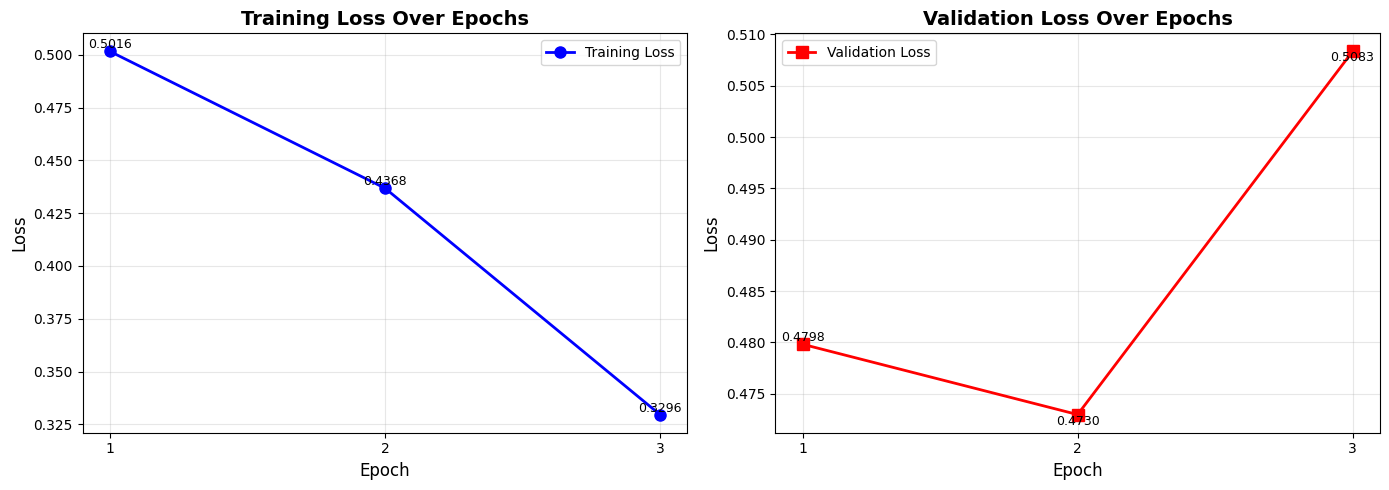


LOSS VALUES SUMMARY
Epoch 1 - Training: 0.5016, Validation: 0.4798
Epoch 2 - Training: 0.4368, Validation: 0.4730
Epoch 3 - Training: 0.3296, Validation: 0.5083


In [14]:
# Training and Validation Loss Graphs (Side by Side)
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training Loss Graph
train_losses_per_epoch = [train_losses[6], train_losses[13], train_losses[20]]
epochs = range(1, len(train_losses_per_epoch) + 1)

ax1.plot(epochs, train_losses_per_epoch, marker='o', label="Training Loss", linewidth=2, markersize=8, color='blue')
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.set_title("Training Loss Over Epochs", fontsize=14, fontweight='bold')
ax1.set_xticks(epochs)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels on training loss points
for i, loss in enumerate(train_losses_per_epoch, 1):
    ax1.text(i, loss, f'{loss:.4f}', ha='center', va='bottom', fontsize=9)

# Validation Loss Graph
ax2.plot(epochs, val_losses, marker='s', label="Validation Loss", linewidth=2, markersize=8, color='red')
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Loss", fontsize=12)
ax2.set_title("Validation Loss Over Epochs", fontsize=14, fontweight='bold')
ax2.set_xticks(epochs)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add value labels on validation loss points
for i, loss in enumerate(val_losses, 1):
    ax2.text(i, loss, f'{loss:.4f}', ha='center', va='bottom' if i==1 else 'top', fontsize=9)

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/results/training_validation_loss_graphs.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("LOSS VALUES SUMMARY")
print("="*50)
print(f"Epoch 1 - Training: {train_losses[6]:.4f}, Validation: {val_losses[0]:.4f}")
print(f"Epoch 2 - Training: {train_losses[13]:.4f}, Validation: {val_losses[1]:.4f}")
print(f"Epoch 3 - Training: {train_losses[20]:.4f}, Validation: {val_losses[2]:.4f}")

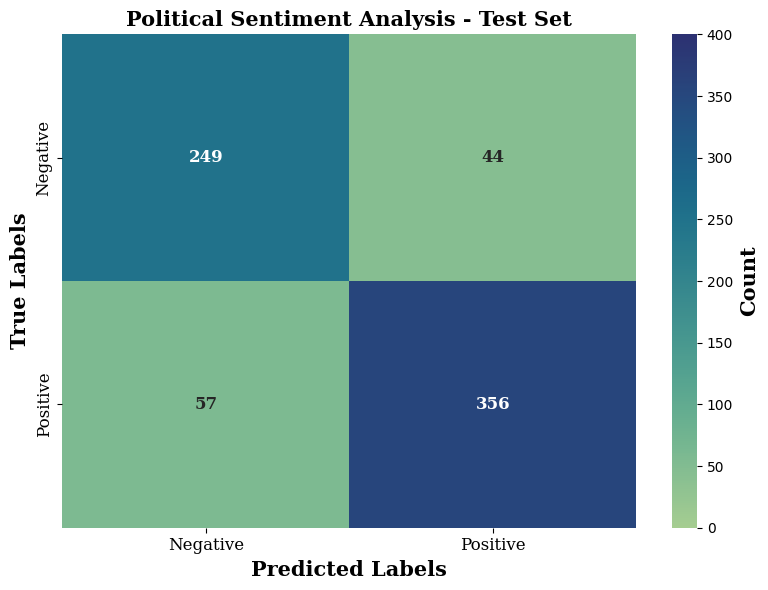

In [15]:
# Test Confusion Matrix Heatmap
plt.figure(figsize=(8,6))

# Define the custom palette
custom_palette = sns.color_palette("crest", as_cmap=True)

# Define custom font dictionary for title and labels
font = {'family': 'Serif', 'weight': 'bold', 'size': 15}

# Create heatmap with annotations and colormap
heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap=custom_palette, vmin=0, vmax=400,
                      xticklabels=['Negative', 'Positive'],
                      yticklabels=['Negative', 'Positive'],
                      annot_kws={"family": "Serif", 'weight': 'bold', 'size': 12})

# Set x and y labels with the custom font dictionary
heatmap.set_xlabel('Predicted Labels', fontdict=font)
heatmap.set_ylabel('True Labels', fontdict=font)
heatmap.set_title('Political Sentiment Analysis - Test Set', fontdict=font)

# Set font properties for tick labels on both axes
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontname='Serif', fontsize=12)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontname='Serif', fontsize=12)

# Create a color bar to indicate the scale
cbar = heatmap.collections[0].colorbar
cbar.set_label('Count', fontdict=font)
cbar.ax.tick_params(labelsize=10)

# Adjust layout to prevent cropping
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/results/test_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# Misclassified results analysis
test_df_analysis = test_df.copy()
test_df_analysis["y_true"] = y_true
test_df_analysis["y_pred"] = y_pred
test_df_analysis["correct"] = (y_true == y_pred)

mis = test_df_analysis[test_df_analysis["correct"] == False]
false_pos = test_df_analysis[(test_df_analysis["y_true"] == 0) & (test_df_analysis["y_pred"] == 1)]
false_neg = test_df_analysis[(test_df_analysis["y_true"] == 1) & (test_df_analysis["y_pred"] == 0)]

print("\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)
print(f"Total Test Samples: {len(test_df_analysis)}")
print(f"Total Misclassified: {len(mis)}")
print(f"False Positives (NEG→POS): {len(false_pos)}")
print(f"False Negatives (POS→NEG): {len(false_neg)}")

def show_examples(title, data, n=5):
    print("\n" + "="*60)
    print(title)
    print("="*60)
    if len(data) == 0:
        print("No examples found")
        return
    sample = data.sample(n=min(n, len(data)), random_state=42)
    for _, row in sample.iterrows():
        true_label = "NEG" if row["y_true"] == 0 else "POS"
        pred_label = "NEG" if row["y_pred"] == 0 else "POS"
        print(f"\nTrue: {true_label} | Pred: {pred_label}")
        text = row["text"][:200] + "..." if len(row["text"]) > 200 else row["text"]
        print(f"Text: {text}")

show_examples("FALSE NEGATIVES (POS predicted as NEG)", false_neg)
show_examples("FALSE POSITIVES (NEG predicted as POS)", false_pos)

# Save error analysis
false_pos.to_csv(f"{BASE_PATH}/results/false_positives.csv", index=False)
false_neg.to_csv(f"{BASE_PATH}/results/false_negatives.csv", index=False)
print("\nError analysis saved to CSV files")


ERROR ANALYSIS
Total Test Samples: 706
Total Misclassified: 101
False Positives (NEG→POS): 44
False Negatives (POS→NEG): 57

FALSE NEGATIVES (POS predicted as NEG)

True: POS | Pred: NEG
Text: নাটোর-৪ আসনের (বড়াইগ্রাম-গুরুদাসপুর) উপ-নির্বাচন আগামী ১১ অক্টোবর অনুষ্ঠিত হবে। এই আসনে ভোটগ্রহণ হবে ব্যালট পেপারে। ভোটকেন্দ্রে থাকবে না সিসি ক্যামেরা। বৃহস্পতিবার (৭ সেপ্টেম্বর) কমিশন সভা শেষে এ তথ্য...

True: POS | Pred: NEG
Text: কিশোর গ্যাং নির্মূলে কঠোর হুশিয়ারি উচ্চারণ করে আওয়ামী লীগের সভাপতিমন্ডলীর সদস্য ও ঢাকা-১৩ আসনের নৌকার প্রার্থী এডভোকেট জাহাঙ্গীর কবির নানক বলেছেন, কোন কিশোর গ্যাং, বড় গ্যাং, মাঝারি গ্যাং; কোন গ্যাং এই...

True: POS | Pred: NEG
Text:  ঢাকা-১৯ (সাভার ও আশুলিয়া) আসনে ইউনিয়ন পরিষদের সাবেক এক চেয়ারম্যানের কাছে প্রতিমন্ত্রীর শোচনীয় পরাজয়ের ঘটনাই এখন সবার মুখে মুখে। এক স্বতন্ত্রের ট্রাকের চাপায় এবং অন্য স্বতন্ত্রের ঈগলের ঝাপটায় ন...

True: POS | Pred: NEG
Text:  দ্বাদশ জাতীয় সংসদ নির্বাচনে কুমিল্লার ১১টি আসনের মধ্যে চারটি আসনে আওয়ামী লীগের মনোনীত নৌকা প্রতীক নিয়ে 

In [17]:
# Dataset Analysis for Motamot
import pandas as pd
import numpy as np
import os
from datetime import datetime

# Paths
RESULTS_PATH = "/content/drive/MyDrive/motamot_xlm/results"
DATA_PATH = "/content/drive/MyDrive/motamot_xlm/preprocessed_dataset"
os.makedirs(RESULTS_PATH, exist_ok=True)

# Load datasets
train = pd.read_csv(f"{DATA_PATH}/Motamot_train_binary.csv")
val = pd.read_csv(f"{DATA_PATH}/Motamot_val_binary.csv")
test = pd.read_csv(f"{DATA_PATH}/Motamot_test_binary.csv")

# Rename columns for consistency
train = train.rename(columns={"text": "text", "label": "label"})
val = val.rename(columns={"text": "text", "label": "label"})
test = test.rename(columns={"text": "text", "label": "label"})

# Add text length columns
train['text_length'] = train['text'].astype(str).apply(len)
train['word_count'] = train['text'].astype(str).apply(lambda x: len(x.split()))

val['text_length'] = val['text'].astype(str).apply(len)
val['word_count'] = val['text'].astype(str).apply(lambda x: len(x.split()))

test['text_length'] = test['text'].astype(str).apply(len)
test['word_count'] = test['text'].astype(str).apply(lambda x: len(x.split()))

# Create full dataset
full_df = pd.concat([train, val, test], ignore_index=True)

# -----------------------
# 1) Overall Dataset Analysis
# -----------------------
print("\n" + "="*70)
print("MOTAMOT DATASET ANALYSIS")
print("="*70)

print("\n1. DATASET DIMENSIONS:")
print(f"   Total samples: {len(full_df)}")
print(f"   Total features: {len(full_df.columns)}")
print(f"   Features: {list(full_df.columns)}")

print("\n2. SPLIT DISTRIBUTION:")
print(f"   Train: {len(train)} samples ({len(train)/len(full_df)*100:.2f}%)")
print(f"   Val:   {len(val)} samples ({len(val)/len(full_df)*100:.2f}%)")
print(f"   Test:  {len(test)} samples ({len(test)/len(full_df)*100:.2f}%)")

print("\n3. CLASS DISTRIBUTION (0=NEG, 1=POS):")
print("   Overall:")
print(f"      Negative (0): {len(full_df[full_df['label']==0])} ({(len(full_df[full_df['label']==0])/len(full_df)*100):.2f}%)")
print(f"      Positive (1): {len(full_df[full_df['label']==1])} ({(len(full_df[full_df['label']==1])/len(full_df)*100):.2f}%)")

print("\n4. TEXT LENGTH STATISTICS (characters):")
print(f"   Min length:  {full_df['text_length'].min()}")
print(f"   Max length:  {full_df['text_length'].max()}")
print(f"   Mean length: {full_df['text_length'].mean():.2f}")
print(f"   Median:      {full_df['text_length'].median():.2f}")
print(f"   Std dev:     {full_df['text_length'].std():.2f}")

print("\n5. WORD COUNT STATISTICS:")
print(f"   Min words:  {full_df['word_count'].min()}")
print(f"   Max words:  {full_df['word_count'].max()}")
print(f"   Mean words: {full_df['word_count'].mean():.2f}")
print(f"   Median:     {full_df['word_count'].median():.2f}")

print("\n6. DATA QUALITY:")
print(f"   Missing values: {full_df.isnull().sum().sum()}")
print(f"   Duplicate texts: {full_df.duplicated(subset=['text']).sum()}")

# -----------------------
# 2) Train/Val/Test Separate Analysis
# -----------------------
print("\n" + "="*70)
print("TRAIN/VAL/TEST SEPARATE ANALYSIS")
print("="*70)

for name, df in [("TRAIN", train), ("VAL", val), ("TEST", test)]:
    print(f"\n{'-'*50}")
    print(f"{name} SET:")
    print(f"{'-'*50}")
    print(f"   Samples: {len(df)}")
    print(f"\n   Class distribution:")
    neg_count = len(df[df['label']==0])
    pos_count = len(df[df['label']==1])
    print(f"      Negative (0): {neg_count} ({neg_count/len(df)*100:.2f}%)")
    print(f"      Positive (1): {pos_count} ({pos_count/len(df)*100:.2f}%)")
    print(f"\n   Text length (chars):")
    print(f"      Min: {df['text_length'].min()}, Max: {df['text_length'].max()}, Mean: {df['text_length'].mean():.2f}")
    print(f"   Word count:")
    print(f"      Min: {df['word_count'].min()}, Max: {df['word_count'].max()}, Mean: {df['word_count'].mean():.2f}")

# -----------------------
# 3) Sample Texts
# -----------------------
print("\n" + "="*70)
print("SAMPLE TEXTS FROM EACH CLASS")
print("="*70)

for name, df in [("TRAIN", train), ("VAL", val), ("TEST", test)]:
    print(f"\n{name} SET:")
    for label in [0, 1]:
        label_name = "NEGATIVE" if label == 0 else "POSITIVE"
        samples = df[df['label'] == label].sample(min(3, len(df[df['label'] == label])), random_state=42)
        print(f"\n   {label_name} (Label {label}) examples:")
        for idx, row in samples.iterrows():
            print(f"      - {row['text'][:150]}...")

# -----------------------
# 4) Save Analysis to File
# -----------------------
with open(f"{RESULTS_PATH}/motamot_dataset_analysis.txt", "w", encoding="utf-8") as f:
    f.write("="*70 + "\n")
    f.write("MOTAMOT DATASET ANALYSIS REPORT\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("="*70 + "\n\n")

    f.write("1. DATASET OVERVIEW\n")
    f.write("-"*50 + "\n")
    f.write(f"Total samples: {len(full_df)}\n")
    f.write(f"Features: {list(full_df.columns)}\n\n")

    f.write("2. DATA SPLITS\n")
    f.write("-"*50 + "\n")
    f.write(f"Train: {len(train)} ({len(train)/len(full_df)*100:.2f}%)\n")
    f.write(f"Val:   {len(val)} ({len(val)/len(full_df)*100:.2f}%)\n")
    f.write(f"Test:  {len(test)} ({len(test)/len(full_df)*100:.2f}%)\n\n")

    f.write("3. CLASS DISTRIBUTION\n")
    f.write("-"*50 + "\n")
    f.write("Overall:\n")
    f.write(f"  Negative (0): {len(full_df[full_df['label']==0])} ({(len(full_df[full_df['label']==0])/len(full_df)*100):.2f}%)\n")
    f.write(f"  Positive (1): {len(full_df[full_df['label']==1])} ({(len(full_df[full_df['label']==1])/len(full_df)*100):.2f}%)\n\n")

    for name, df in [("Train", train), ("Validation", val), ("Test", test)]:
        f.write(f"  {name}:\n")
        neg_count = len(df[df['label']==0])
        pos_count = len(df[df['label']==1])
        f.write(f"    Neg: {neg_count} ({neg_count/len(df)*100:.2f}%), Pos: {pos_count} ({pos_count/len(df)*100:.2f}%)\n")

    f.write("\n4. TEXT LENGTH STATISTICS\n")
    f.write("-"*50 + "\n")
    f.write(f"Characters - Min: {full_df['text_length'].min()}, Max: {full_df['text_length'].max()}, ")
    f.write(f"Mean: {full_df['text_length'].mean():.2f}, Median: {full_df['text_length'].median():.2f}\n")
    f.write(f"Words - Min: {full_df['word_count'].min()}, Max: {full_df['word_count'].max()}, ")
    f.write(f"Mean: {full_df['word_count'].mean():.2f}, Median: {full_df['word_count'].median():.2f}\n\n")

    f.write("5. DETAILED SPLIT STATISTICS\n")
    f.write("-"*50 + "\n")
    for name, df in [("Train", train), ("Validation", val), ("Test", test)]:
        f.write(f"\n{name}:\n")
        f.write(f"  Samples: {len(df)}\n")
        f.write(f"  Text length - Min: {df['text_length'].min()}, Max: {df['text_length'].max()}, Mean: {df['text_length'].mean():.2f}\n")
        f.write(f"  Word count  - Min: {df['word_count'].min()}, Max: {df['word_count'].max()}, Mean: {df['word_count'].mean():.2f}\n")

    f.write("\n6. DATA QUALITY\n")
    f.write("-"*50 + "\n")
    f.write(f"Missing values: {full_df.isnull().sum().sum()}\n")
    f.write(f"Duplicate texts: {full_df.duplicated(subset=['text']).sum()}\n")

print("\n" + "="*70)
print(f"Analysis saved to: {RESULTS_PATH}/motamot_dataset_analysis.txt")
print("="*70)

# Optional: Save summary CSV
summary_data = {
    'Split': ['Train', 'Validation', 'Test', 'Overall'],
    'Samples': [len(train), len(val), len(test), len(full_df)],
    'Negative': [len(train[train['label']==0]), len(val[val['label']==0]), len(test[test['label']==0]), len(full_df[full_df['label']==0])],
    'Positive': [len(train[train['label']==1]), len(val[val['label']==1]), len(test[test['label']==1]), len(full_df[full_df['label']==1])],
    'Avg_Word_Count': [train['word_count'].mean(), val['word_count'].mean(), test['word_count'].mean(), full_df['word_count'].mean()]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(f"{RESULTS_PATH}/motamot_dataset_summary.csv", index=False)
print(f"Summary CSV saved to: {RESULTS_PATH}/motamot_dataset_summary.csv")


MOTAMOT DATASET ANALYSIS

1. DATASET DIMENSIONS:
   Total samples: 7058
   Total features: 4
   Features: ['text', 'label', 'text_length', 'word_count']

2. SPLIT DISTRIBUTION:
   Train: 5647 samples (80.01%)
   Val:   705 samples (9.99%)
   Test:  706 samples (10.00%)

3. CLASS DISTRIBUTION (0=NEG, 1=POS):
   Overall:
      Negative (0): 2926 (41.46%)
      Positive (1): 4132 (58.54%)

4. TEXT LENGTH STATISTICS (characters):
   Min length:  29
   Max length:  24267
   Mean length: 1354.82
   Median:      1176.00
   Std dev:     1031.83

5. WORD COUNT STATISTICS:
   Min words:  4
   Max words:  3566
   Mean words: 201.31
   Median:     175.00

6. DATA QUALITY:
   Missing values: 0
   Duplicate texts: 107

TRAIN/VAL/TEST SEPARATE ANALYSIS

--------------------------------------------------
TRAIN SET:
--------------------------------------------------
   Samples: 5647

   Class distribution:
      Negative (0): 2341 (41.46%)
      Positive (1): 3306 (58.54%)

   Text length (chars):
   